<a href="https://colab.research.google.com/github/henriqueerss/fiap_introRedesNeurais_IA/blob/main/GENAI02_IntroRedesNeurais.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# IMPORTANDO BIBLIOTECAS:

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Gerar dados 2D em 2 classes:
np.random.seed(42)
N = 100
x_class0 = np.random.randn(N, 2) + np.array([-2, -2])
x_class1 = np.random.randn(N, 2) + np.array([2, 2])
X = np.vstack([x_class0, x_class1])
y = np.array([0]*N + [1]*N).reshape(-1, 1)

# CRIANDO UM DATASET ARTIFICIAL

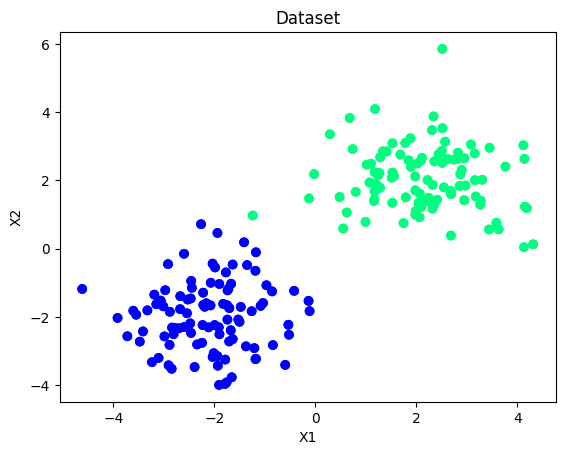

In [4]:
plt.scatter(X[:,0],X[:,1], c=Y, cmap='winter')

#Visualizar os dados:
plt.scatter(X[:,0],X[:,1], c=Y, cmap='winter')
plt.title('Dataset')
plt.xlabel('X1')
plt.ylabel('X2')
plt.show()

# REDE NEURAL COM ARQUITETURA: 2 input nodes -> 3 hiddens -> 1 output;

In [7]:
def sigmoid(x):
  return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
  return sigmoid(x) * (1 - sigmoid(x))

learning_rate = 0.01

# Inicializar pesos e vieses
np.random.seed(0)
W1 = np.random.randn(2, 3)
b1 = np.zeros((1, 3))
W2 = np.random.randn(3, 1)
b2 = np.zeros((1, 1))

for epoch in range(1000):
  # Forward pass:
  z1 = X @ W1 + b1
  a1 = sigmoid(z1)
  z2 = a1 @ W2 + b2
  y_pred = sigmoid(z2)

  # Perda (MSE - Mean Squared Error)
  loss = np.mean((y_pred - Y) ** 2)

  # Backward pass:
  dz2 = (y_pred - Y) * sigmoid_derivative(z2)
  dW2 = a1.T @ dz2
  db2 = np.sum(dz2, axis=0, keepdims=True)

  da1 = dz2 @ W2.T
  dz1 = da1 * sigmoid_derivative(z1)
  dW1 = X.T @ dz1
  db1 = np.sum(dz1, axis=0, keepdims=True)


  # Atualizar pesos:
  W1 -= learning_rate * dW1
  b1 -= learning_rate * db1
  W2 -= learning_rate * dW2
  b2 -= learning_rate * db2

  if epoch % 100 == 0:
    print(f'Epoch {epoch}, Loss: {loss:.4f}')

Epoch 0, Loss: 0.1710
Epoch 100, Loss: 0.0074
Epoch 200, Loss: 0.0034
Epoch 300, Loss: 0.0023
Epoch 400, Loss: 0.0017
Epoch 500, Loss: 0.0014
Epoch 600, Loss: 0.0012
Epoch 700, Loss: 0.0010
Epoch 800, Loss: 0.0009
Epoch 900, Loss: 0.0008


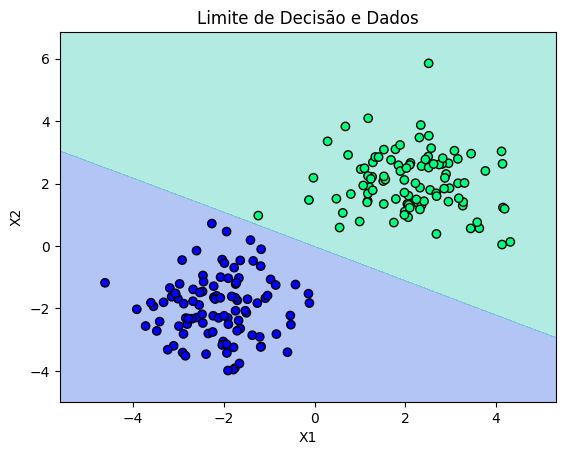

In [8]:
# Mostrar função usando os pesos 'aprendidos'
def predict(X):
  z1 = X @ W1 + b1
  a1 = sigmoid(z1)
  z2 = a1 @ W2 + b2
  return sigmoid(z2)

# Criar uma tabela de pontos sobre a dispersão de camadas
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                     np.linspace(y_min, y_max, 100))
grid = np.c_[xx.ravel(), yy.ravel()]

# Prever probabilidades para cada ponto na tabela
probs = predict(grid).reshape(xx.shape)

# Plotar limite entre decisões e dados
plt.contourf(xx, yy, probs, levels=[0, 0.5, 1], cmap="winter", alpha=0.3)
plt.scatter(X[:, 0], X[:, 1], c=Y, cmap="winter", edgecolors='k')
plt.title('Limite de Decisão e Dados')
plt.xlabel('X1')
plt.ylabel('X2')
plt.show()